In [1]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama.llms import OllamaLLM
from langchain_chroma import Chroma
from langchain_ollama import OllamaEmbeddings
from rag_evaluator import RAGEvaluator
from langchain.chains.query_constructor.schema import AttributeInfo
from langchain.retrievers.self_query.base import SelfQueryRetriever

In [2]:
class rag_10k:
    def __init__(self, metadata_field_info, document_content_description, vector_store,llm, prompt):
        self.metadata_field_info = metadata_field_info
        self.document_content_description = document_content_description
        self.vector_store = vector_store
        self.llm = llm 
        self.prompt = prompt
    def retrieve_context(self,question):
        #Define Retriever
        try:
            retriever = SelfQueryRetriever.from_llm(
                self.llm,
                self.vector_store,
                self.document_content_description,
                self.metadata_field_info,
            )
            retrieved_docs = retriever.invoke(question)
        except:
             retrieved_docs = self.vector_store.similarity_search(question)
        if(len(retrieved_docs) == 0):
             retrieved_docs = self.vector_store.similarity_search(question)
        return retrieved_docs
    def generate_response(self, question, context):
            docs_content = "\n\n".join(doc.page_content for doc in context)
            messages = self.prompt.invoke({"question": question, "context": docs_content})
            response = self.llm.invoke(messages)
            return response

In [3]:
embeddings_model = OllamaEmbeddings(model="all-minilm")
vector_store_semantic_sections = Chroma(
    collection_name="example_collection",
    embedding_function=embeddings_model,
    persist_directory="./chroma_langchain_db"
)

In [ ]:
embeddings_model = OllamaEmbeddings(model="all-minilm")
vector_store_manual = Chroma(
    collection_name="k-10s",
    embedding_function=embeddings_model,
    persist_directory="./chroma_langchain_db-Nick/chroma_langchain_db"
)

In [5]:
embeddings_model = OllamaEmbeddings(model="all-minilm")
vector_store_semantic = Chroma(
    collection_name="example_collection",
    embedding_function=embeddings_model,
    persist_directory="./chroma_semantic_chunking"
)

In [6]:


metadata_field_info = [
    AttributeInfo(
        name="ticker",
        description="Abbreviation of the company associated with the 10-K filing from which the text was extracted known as the ticker or stock symbol",
        type="string",
    )
]
document_content_description = "Collection of 10-K filings from various companies."


llm = OllamaLLM(model="llama3.1")

template = """Use the following context: {context} to answer the question: {question}
If you do not know the answer, just say "I don't know".  Don't make up any answers

Answer: Provide a concise answer to the question based on extracted information from the documents."""

prompt = ChatPromptTemplate.from_template(template)


In [7]:
rag_semantic_sections =  rag_10k(metadata_field_info=metadata_field_info,
              document_content_description=document_content_description,
              vector_store=vector_store_semantic_sections,
              llm = llm,prompt=prompt)

In [ ]:
rag_manual = rag_10k(metadata_field_info=metadata_field_info,
              document_content_description=document_content_description,
              vector_store=vector_store_manual,
              llm = llm,prompt=prompt)


In [9]:
rag_semantic = rag_10k(metadata_field_info=metadata_field_info,
              document_content_description=document_content_description,
              vector_store=vector_store_semantic,
              llm = llm,prompt=prompt)

In [10]:
#define list of queries and responses to test model on

sample_queries = [
    "What are the risks associated with Agilent?",
    "When was the Iphone 12 released?",
    "How does Google make money?",
    "Where does most of General Motor's cash come from?",
    "What are NVDIA's key strategies?",
]

expected_responses = [
    "The biggest risks to Agilent's business are the COVID-19 pandemic, markets where they sell their products decline or do not grow as anticipated, and failure to adjust to market conditions or introduce new products in a timely manner",
    "The Iphone 12 was released in October 2020.",
    "The primary way Google makes money is through Brand and Performance advertising.",
    "General Motor's makes money through finance charge income, leasing income and proceeds from the sale of terminated leased vehicles, net distributions from credit facilities, securitizations, secured and unsecured borrowings and collections and recoveries on finance receivables",
    "NVDIA's key strategies include Advancing the GPU computing platform, Extending the technology and platform leadership in AI, Extending the technology and platform leadership in visual computing, Advancing the leading autonomous vehicle platform, and Leveraging their intellectual property"
    
]

In [11]:
#generate dictionary of questions, expected responses, and responses from the rag for evaluation
def get_rag_comparison_dict(question_list, answer_list, rag):
    results = {}
    result_list =[]
    for query_id, (question,gt_answer) in enumerate(zip(question_list, answer_list)):
        query_dict = {}
        context = rag.retrieve_context(question)
        response = rag.generate_response(question, context)
        retrieved_context = []
        for doc in context:
            doc_dict = {}
            try:
                doc_dict["ticker"] = doc.metadata["ticker"]
            except:
                doc_dict["ticker"] =""
            doc_dict["text"] = doc.page_content
            retrieved_context.append(doc_dict)

        query_dict["query_id"] = query_id
        query_dict["query"] = question
        query_dict["response"] = response
        query_dict["gt_answer"] = gt_answer
        query_dict["retrieved_context"] = retrieved_context
        result_list.append(query_dict)
    results["results"] = result_list
    return results


In [12]:
rag_comparison_dict_semantic_section = get_rag_comparison_dict(sample_queries,expected_responses,rag_semantic_sections)

In [ ]:
rag_comparison_dict_manual = get_rag_comparison_dict(sample_queries,expected_responses,rag_manual)

In [14]:
rag_comparison_dict_semantic = get_rag_comparison_dict(sample_queries,expected_responses,rag_semantic)

In [15]:
def evaluate_model(rag_comp_dict):
    # Evaluate the Generator
    evaluator = RAGEvaluator()
    query_dict = {}
    query_scores = []
    for query in rag_comp_dict["results"]:
        metrics = evaluator.evaluate_all(query["query"], query["response"], query["gt_answer"])
        query_scores.append(metrics)
        query_dict[query["query"]] = [query["response"], query["gt_answer"], metrics]

    #Get average score for each metric
    sums ={}
    counts = {} 
    for query in query_scores:
        for metric, value in query.items():
            # Sum up the values
            sums[metric] = sums.get(metric, 0) + value
            # Count the occurrences of each key
            counts[metric] = counts.get(metric, 0) + 1
    average_metrics = {key: sums[key] / counts[key] for key in sums}
    return query_dict,average_metrics


In [16]:
query_dict_semantic_sections, avg_metrics_semantic_sections = evaluate_model(rag_comparison_dict_semantic_section)

Device set to use cpu
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.
`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.


In [ ]:
query_dict_manual, avg_metrics_manual = evaluate_model(rag_comparison_dict_manual)

Device set to use cpu
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.


In [18]:
query_dict_semantic, avg_metrics_semantic = evaluate_model(rag_comparison_dict_semantic)

Device set to use cpu
Failed to determine 'entailment' label id from the label2id mapping in the model config. Setting to -1. Define a descriptive label2id mapping in the model config to ensure correct outputs.


In [19]:
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
llm_results = {
    "RAG_SEMANTIC_SECTIONS": avg_metrics_semantic_sections,
    "RAG_manual": avg_metrics_manual,
    "RAG_SEMANTIC": avg_metrics_semantic,
}

metrics = ['BLEU','ROUGE-1','BERT P','BERT R','BERT F1','Perplexity','Diversity','Racial Bias']
llms = list(llm_results.keys())
data = {metric: [llm_results[llm][metric] for llm in llms] for metric in metrics}

In [21]:
import pandas as pd

In [31]:
rag_comparison_df = pd.DataFrame(data, index = ["RAG_SEMANTIC_SECTIONS","RAG_MANUAL","RAG_SEMANTIC"]).reset_index()

In [23]:
rag_comparison_df.columns

Index(['index', 'BLEU', 'ROUGE-1', 'BERT P', 'BERT R', 'BERT F1', 'Perplexity',
       'Diversity', 'Racial Bias'],
      dtype='object')

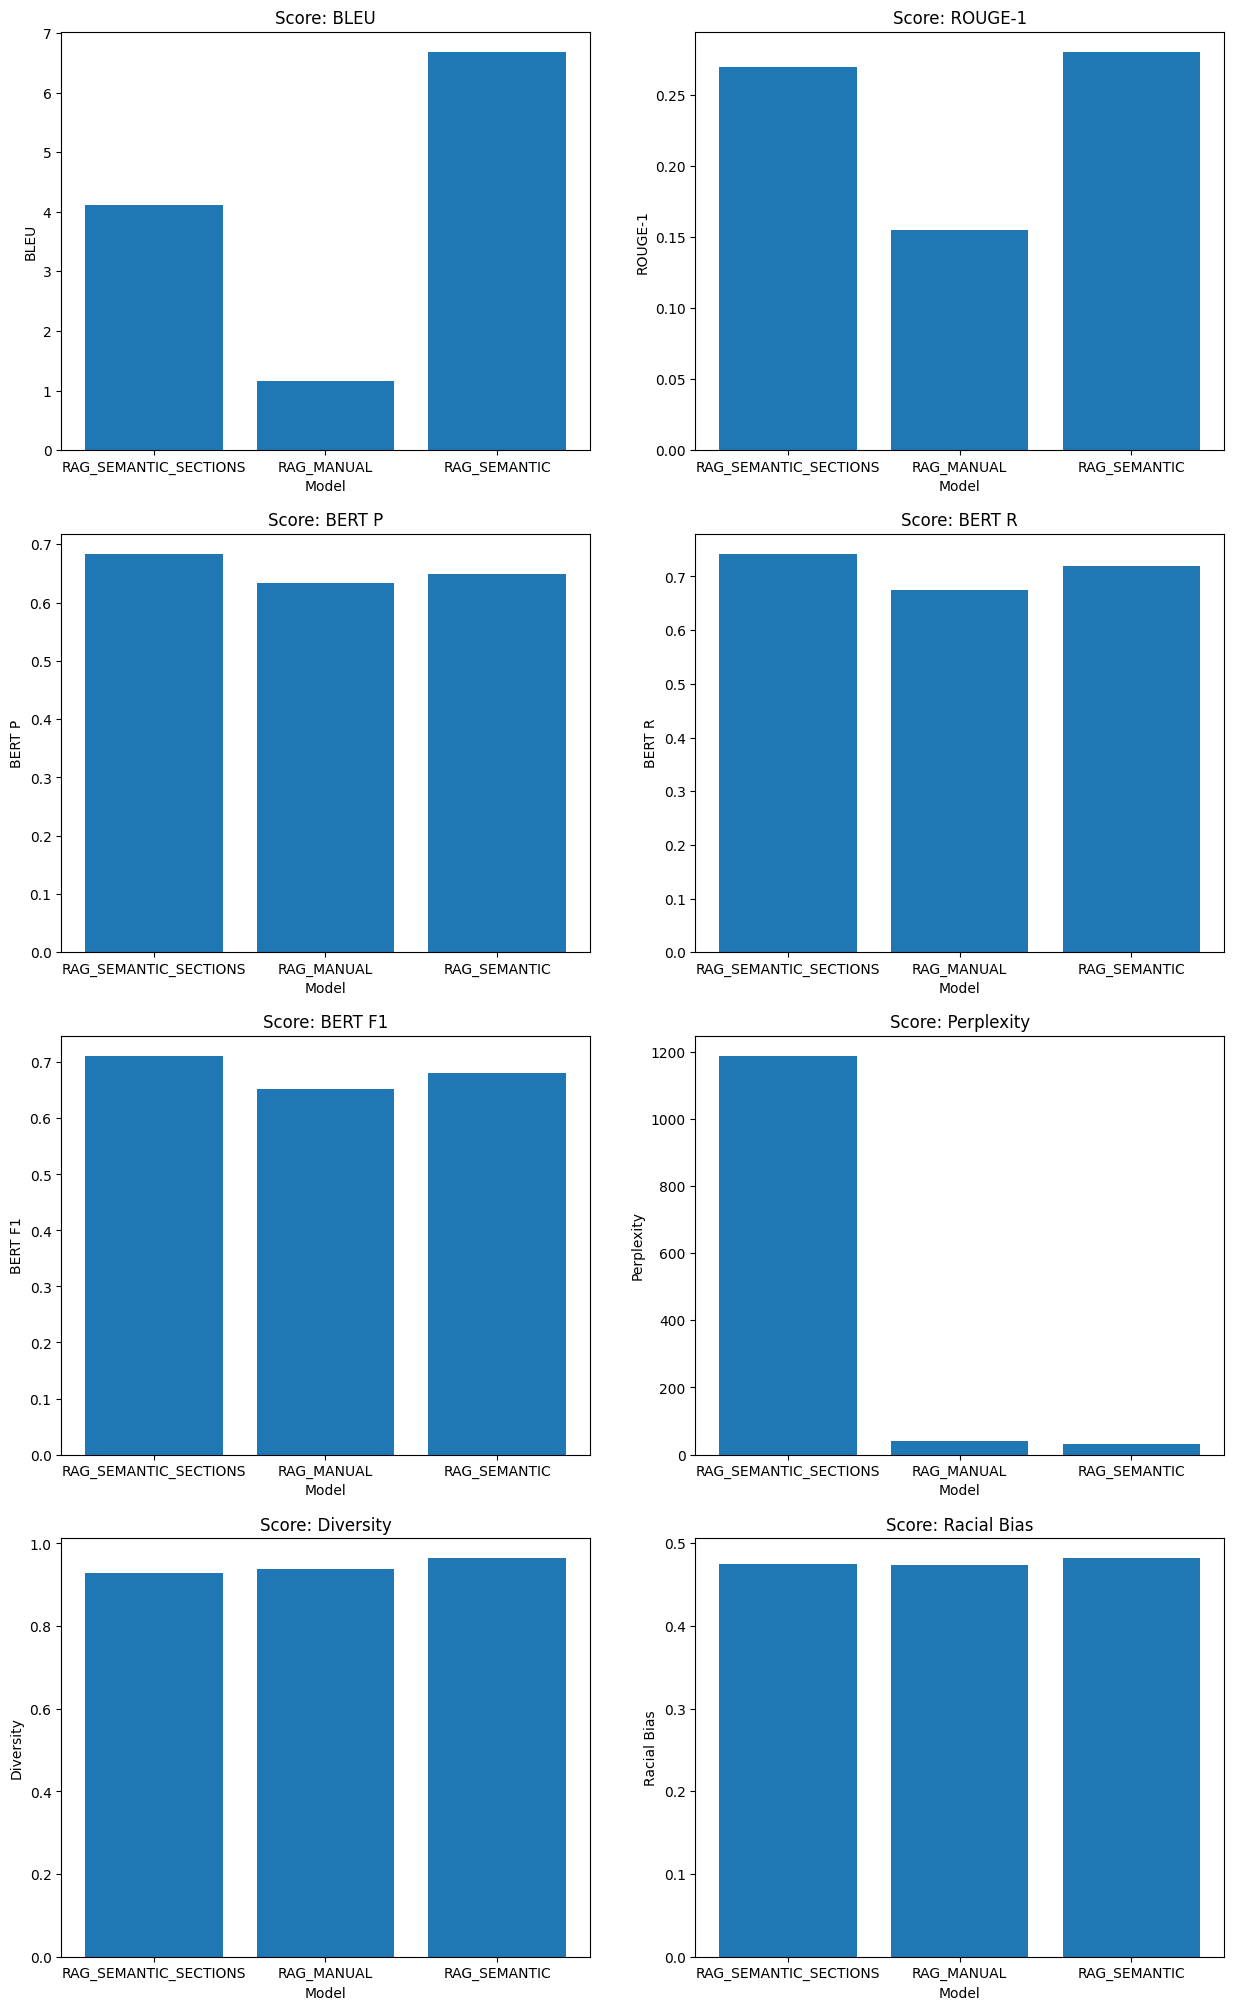

In [32]:
fig, axes = plt.subplots(4, 2, figsize=(15, 25))
axes = axes.flatten()
for x, score in enumerate(rag_comparison_df.columns[1:]):
    score_data = rag_comparison_df[["index",score]]
    axes[x].bar(score_data["index"], score_data[score])
    axes[x].set_title(f"Score: {score}")
    axes[x].set_xlabel("Model")
    axes[x].set_ylabel(f"{score}")